In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder
from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ==========================================================
# 2. KONFIGURASI
# ==========================================================
FILE_PATH = "datasets/baznas-5.csv"
TARGET = "KELAS TARGET"
RIWAYAT = "RIWAYAT PENERIMA BANTUAN (0-3)"
RANDOM_STATE = 42

# Urutan kelas wajib dibuat eksplisit agar tabel dan heatmap
# menggunakan arti TN, FP, FN, TP yang sama.
CLASS_ORDER = ["TIDAK LAYAK", "LAYAK"]
CLASS_DISPLAY = ["Tidak Layak", "Layak"]

# ==========================================================
# 3. MEMBACA DATASET
# ==========================================================
df = pd.read_csv(FILE_PATH)

print("Jumlah data:", df.shape)
print("\nKolom:")
print(df.columns.tolist())

print("\nDistribusi kelas:")
print(df[TARGET].value_counts())

print("\nMissing value:")
print(df.isnull().sum())

Jumlah data: (194, 13)

Kolom:
['NO', 'NAMA', 'SUAMI', 'ISTRI', 'JENIS USAHA/PEKERJAAN', 'KEPEMILIKAN ASET', 'LUAS TEMPAT TINGGAL', 'JENIS DINDING', 'JENIS LANTAI', 'PENDIDIKAN', 'JUMLAH TANGGUNGAN', 'RIWAYAT', 'KELAS TARGET']

Distribusi kelas:
KELAS TARGET
LAYAK          119
TIDAK LAYAK     75
Name: count, dtype: int64

Missing value:
NO                       0
NAMA                     0
SUAMI                    0
ISTRI                    0
JENIS USAHA/PEKERJAAN    0
KEPEMILIKAN ASET         0
LUAS TEMPAT TINGGAL      0
JENIS DINDING            0
JENIS LANTAI             0
PENDIDIKAN               0
JUMLAH TANGGUNGAN        8
RIWAYAT                  0
KELAS TARGET             0
dtype: int64


In [2]:
# ==========================================================
# 4. DATA CLEANING
# ==========================================================

# Merapikan spasi pada kolom teks
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()

# Konversi kolom pendapatan menjadi numerik
df["SUAMI"] = pd.to_numeric(df["SUAMI"], errors="coerce").fillna(0)
df["ISTRI"] = pd.to_numeric(df["ISTRI"], errors="coerce").fillna(0)

# Konversi jumlah tanggungan
df["JUMLAH TANGGUNGAN"] = pd.to_numeric(
    df["JUMLAH TANGGUNGAN"],
    errors="coerce"
).fillna(0)

# Pastikan riwayat bantuan hanya pada skala 0 sampai 3
df['RIWAYAT'] = pd.to_numeric(
    df['RIWAYAT'],
    errors="coerce"
).fillna(0)

df['RIWAYAT'] = df['RIWAYAT'].clip(0, 3).astype(int)

# Menghapus duplikasi berdasarkan Nomor KK
# df = df.drop_duplicates(subset=["NO KARTU KELUARGA"])

# Menghapus data tanpa kelas target
df = df.dropna(subset=["RIWAYAT"]).copy()

print("Jumlah data setelah cleaning:", df.shape)


df.head()  # Tampilkan 5 baris pertama dataset setelah cleaning

Jumlah data setelah cleaning: (194, 13)


,NO,NAMA,SUAMI,ISTRI,JENIS USAHA/PEKERJAAN,KEPEMILIKAN ASET,LUAS TEMPAT TINGGAL,JENIS DINDING,JENIS LANTAI,PENDIDIKAN,JUMLAH TANGGUNGAN,RIWAYAT,KELAS TARGET
0,1,Vadillah Kasim,300000,350000,Berdagang,Tidak ada,Sedang,Semi,Semen,SLTA/Sederajat,3.0,0,LAYAK
1,2,Hajira Van Gobel,500000,750000,Berdagang,Tidak ada,Sedang,Tembok/beton,Keramik,Diploma I,3.0,0,LAYAK
2,3,Ratu Abantu,1500000,500000,Berdagang,Tidak ada,Kecil,Tembok/beton,Semen,Tamat SD,6.0,2,LAYAK
3,4,Aminah Akib,500000,750000,Berdagang,Tidak ada,Sedang,Tembok/beton,Semen,SLTA/Sederajat,6.0,1,LAYAK
4,5,Nurmin Blongkod,0,500000,Berdagang,Tidak ada,Kecil,Tembok/beton,Semen,SLTA/Sederajat,1.0,1,LAYAK


In [3]:
# ==========================================================
# 5. FEATURE ENGINEERING
# ==========================================================

# Total pendapatan keluarga
df["TOTAL_PENDAPATAN"] = df["SUAMI"] + df["ISTRI"]

# Pendapatan per kapita
df["PENDAPATAN_PER_KAPITA"] = (
    df["TOTAL_PENDAPATAN"] /
    (df["JUMLAH TANGGUNGAN"] + 1)
)

# Kategori pendapatan
def kategori_pendapatan(nilai):
    if nilai <= 850_000:
        return "Sangat Rendah"
    elif nilai <= 1_700_000:
        return "Rendah"
    elif nilai <= 3_400_000:
        return "Sedang"
    else:
        return "Tinggi"

# Kategori jumlah tanggungan
def kategori_tanggungan(nilai):
    if nilai <= 1:
        return "Rendah"
    elif nilai <= 4:
        return "Sedang"
    else:
        return "Tinggi"

df["KATEGORI_TOTAL_PENDAPATAN"] = (
    df["TOTAL_PENDAPATAN"]
    .apply(kategori_pendapatan)
)

df["KATEGORI_PENDAPATAN_PER_KAPITA"] = (
    df["PENDAPATAN_PER_KAPITA"]
    .apply(kategori_pendapatan)
)

df["KATEGORI_TANGGUNGAN"] = (
    df["JUMLAH TANGGUNGAN"]
    .apply(kategori_tanggungan)
)

# Kategori riwayat bantuan
df["KATEGORI_RIWAYAT"] = df['RIWAYAT'].map({
    0: "Belum Pernah",
    1: "1 Kali",
    2: "2 Kali",
    3: "3 Kali atau Lebih"
})

print(
    df[
        [
            "TOTAL_PENDAPATAN",
            "PENDAPATAN_PER_KAPITA",
            "KATEGORI_TOTAL_PENDAPATAN",
            "KATEGORI_PENDAPATAN_PER_KAPITA",
            "KATEGORI_TANGGUNGAN",
            "KATEGORI_RIWAYAT"
        ]
    ].head()
)

   TOTAL_PENDAPATAN  PENDAPATAN_PER_KAPITA KATEGORI_TOTAL_PENDAPATAN  \
0            650000          162500.000000             Sangat Rendah   
1           1250000          312500.000000                    Rendah   
2           2000000          285714.285714                    Sedang   
3           1250000          178571.428571                    Rendah   
4            500000          250000.000000             Sangat Rendah   

  KATEGORI_PENDAPATAN_PER_KAPITA KATEGORI_TANGGUNGAN KATEGORI_RIWAYAT  
0                  Sangat Rendah              Sedang     Belum Pernah  
1                  Sangat Rendah              Sedang     Belum Pernah  
2                  Sangat Rendah              Tinggi           2 Kali  
3                  Sangat Rendah              Tinggi           1 Kali  
4                  Sangat Rendah              Rendah           1 Kali  


In [4]:
# ==========================================================
# 6. MENENTUKAN FITUR MODEL
# ==========================================================

# Catatan: "KEPEMILIKAN ASET" TIDAK dipakai sebagai fitur pada kedua
# algoritma (Naive Bayes & C4.5) karena nilainya menentukan KELAS TARGET
# 100% (data leakage). Kolomnya tetap ditampilkan di form web, hanya
# saja tidak dijadikan variabel pembelajaran model.

fitur_tanpa_riwayat = [
    "JENIS USAHA/PEKERJAAN",
    "LUAS TEMPAT TINGGAL",
    "JENIS DINDING",
    "JENIS LANTAI",
    "PENDIDIKAN",
    "KATEGORI_TOTAL_PENDAPATAN",
    "KATEGORI_PENDAPATAN_PER_KAPITA",
    "KATEGORI_TANGGUNGAN"
]

fitur_dengan_riwayat = fitur_tanpa_riwayat + [
    "KATEGORI_RIWAYAT"
]


In [5]:
# ==========================================================
# 7. FUNGSI EVALUASI
# ==========================================================

def buat_confusion_matrix(y_true, y_pred):
    """
    Membentuk confusion matrix dengan urutan kelas yang konsisten:
    baris/kolom 0 = TIDAK LAYAK (kelas negatif)
    baris/kolom 1 = LAYAK (kelas positif)

    Dengan urutan ini, cm.ravel() selalu menghasilkan:
    TN, FP, FN, TP.
    """
    return confusion_matrix(
        y_true,
        y_pred,
        labels=CLASS_ORDER
    )


def plot_confusion_matrix(y_true, y_pred, judul):
    """Menampilkan heatmap dengan label yang sesuai dengan isi matriks."""
    cm = buat_confusion_matrix(y_true, y_pred)

    cm_df = pd.DataFrame(
        cm,
        index=[f"Aktual {label}" for label in CLASS_DISPLAY],
        columns=[f"Prediksi {label}" for label in CLASS_DISPLAY]
    )

    plt.figure(figsize=(6, 4))
    sns.heatmap(
        cm_df,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False
    )
    plt.xlabel("Kelas Prediksi")
    plt.ylabel("Kelas Aktual")
    plt.title(judul)
    plt.tight_layout()
    plt.show()

    return cm


def evaluasi_model(nama_model, y_true, y_pred):
    cm = buat_confusion_matrix(y_true, y_pred)

    # Valid karena CLASS_ORDER = [kelas negatif, kelas positif].
    tn, fp, fn, tp = cm.ravel()

    hasil = {
        "Model": nama_model,
        "Accuracy": round(accuracy_score(y_true, y_pred), 4),
        "Precision_LAYAK": round(
            precision_score(
                y_true,
                y_pred,
                pos_label="LAYAK",
                zero_division=0
            ),
            4
        ),
        "Recall_LAYAK": round(
            recall_score(
                y_true,
                y_pred,
                pos_label="LAYAK",
                zero_division=0
            ),
            4
        ),
        "F1_LAYAK": round(
            f1_score(
                y_true,
                y_pred,
                pos_label="LAYAK",
                zero_division=0
            ),
            4
        ),
        "True_Negative": int(tn),
        "False_Positive": int(fp),
        "False_Negative": int(fn),
        "True_Positive": int(tp)
    }

    print(f"\n===== {nama_model} =====")

    print("\nConfusion Matrix:")
    print(
        pd.DataFrame(
            cm,
            index=[f"Aktual {label}" for label in CLASS_DISPLAY],
            columns=[f"Prediksi {label}" for label in CLASS_DISPLAY]
        )
    )

    print("\nClassification Report:")
    print(
        classification_report(
            y_true,
            y_pred,
            labels=CLASS_ORDER,
            target_names=CLASS_DISPLAY,
            digits=4,
            zero_division=0
        )
    )

    return hasil


In [6]:
# ==========================================================
# 8. MODEL NAIVE BAYES + CROSS VALIDATION
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    make_scorer
)

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)

from sklearn.preprocessing import (
    OrdinalEncoder,
    FunctionTransformer
)

from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import CategoricalNB


def tambah_satu(X):
    """
    Mengubah kategori tidak dikenal dari -1 menjadi 0
    dan kategori yang dikenal dimulai dari 1.
    """
    return X.astype(int) + 1


def jalankan_naive_bayes(df_model, fitur, nama_skenario):

    X = df_model[fitur].fillna("Tidak Diketahui").astype(str)
    y = df_model[TARGET].astype(str)

    # ======================================================
    # CROSS VALIDATION
    # ======================================================

    # Pipeline diperlukan agar encoder dilatih ulang
    # pada setiap fold dan mencegah data leakage.
    pipeline_cv = Pipeline([
        (
            "encoder",
            OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1
            )
        ),
        (
            "tambah_satu",
            FunctionTransformer(
                tambah_satu,
                validate=False
            )
        ),
        (
            "naive_bayes",
            CategoricalNB(alpha=1.0)
        )
    ])

    stratified_kfold = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    scoring = {
        "accuracy": make_scorer(accuracy_score),

        "precision": make_scorer(
            precision_score,
            pos_label="LAYAK",
            zero_division=0
        ),

        "recall": make_scorer(
            recall_score,
            pos_label="LAYAK",
            zero_division=0
        ),

        "f1": make_scorer(
            f1_score,
            pos_label="LAYAK",
            zero_division=0
        )
    }

    hasil_cv = cross_validate(
        estimator=pipeline_cv,
        X=X,
        y=y,
        cv=stratified_kfold,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )

    print("\n" + "=" * 65)
    print(f"5-FOLD CROSS-VALIDATION NAIVE BAYES - {nama_skenario}")
    print("=" * 65)

    for fold in range(5):
        print(
            f"Fold {fold + 1}: "
            f"Accuracy={hasil_cv['test_accuracy'][fold]:.4f} | "
            f"Precision={hasil_cv['test_precision'][fold]:.4f} | "
            f"Recall={hasil_cv['test_recall'][fold]:.4f} | "
            f"F1-Score={hasil_cv['test_f1'][fold]:.4f}"
        )

    print("\nRata-rata Cross-Validation:")

    print(
        f"Accuracy  : "
        f"{hasil_cv['test_accuracy'].mean():.4f} "
        f"± {hasil_cv['test_accuracy'].std():.4f}"
    )

    print(
        f"Precision : "
        f"{hasil_cv['test_precision'].mean():.4f} "
        f"± {hasil_cv['test_precision'].std():.4f}"
    )

    print(
        f"Recall    : "
        f"{hasil_cv['test_recall'].mean():.4f} "
        f"± {hasil_cv['test_recall'].std():.4f}"
    )

    print(
        f"F1-Score  : "
        f"{hasil_cv['test_f1'].mean():.4f} "
        f"± {hasil_cv['test_f1'].std():.4f}"
    )

    # ======================================================
    # HOLDOUT TEST 80:20
    # ======================================================

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        stratify=y,
        random_state=RANDOM_STATE
    )

    # Encoding kategori menjadi angka
    encoder = OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1
    )

    X_train_encoded = (
        encoder.fit_transform(X_train).astype(int) + 1
    )

    X_test_encoded = (
        encoder.transform(X_test).astype(int) + 1
    )

    # Training Naive Bayes
    model_nb = CategoricalNB(alpha=1.0)

    model_nb.fit(
        X_train_encoded,
        y_train
    )

    # Prediksi
    y_pred = model_nb.predict(X_test_encoded)

    # ======================================================
    # CONFUSION MATRIX
    # ======================================================

    plot_confusion_matrix(
        y_test,
        y_pred,
        f"Confusion Matrix Naive Bayes - {nama_skenario}"
    )

    # ======================================================
    # PROBABILITAS PREDIKSI
    # ======================================================

    probabilitas = model_nb.predict_proba(
        X_test_encoded
    )

    # Menentukan posisi kelas berdasarkan model.classes_
    indeks_tidak_layak = np.where(
        model_nb.classes_ == "TIDAK LAYAK"
    )[0][0]

    indeks_layak = np.where(
        model_nb.classes_ == "LAYAK"
    )[0][0]

    hasil = evaluasi_model(
        f"Naive Bayes - {nama_skenario}",
        y_test,
        y_pred
    )

    hasil_prediksi = X_test.copy()

    hasil_prediksi["AKTUAL"] = y_test.values
    hasil_prediksi["PREDIKSI"] = y_pred

    hasil_prediksi["PROBABILITAS_TIDAK_LAYAK"] = (
        probabilitas[:, indeks_tidak_layak]
    )

    hasil_prediksi["PROBABILITAS_LAYAK"] = (
        probabilitas[:, indeks_layak]
    )

    # Return tetap sama seperti kode awal
    return hasil, hasil_prediksi, model_nb, encoder


5-FOLD CROSS-VALIDATION NAIVE BAYES - Tanpa Riwayat Bantuan
Fold 1: Accuracy=1.0000 | Precision=1.0000 | Recall=1.0000 | F1-Score=1.0000
Fold 2: Accuracy=1.0000 | Precision=1.0000 | Recall=1.0000 | F1-Score=1.0000
Fold 3: Accuracy=1.0000 | Precision=1.0000 | Recall=1.0000 | F1-Score=1.0000
Fold 4: Accuracy=1.0000 | Precision=1.0000 | Recall=1.0000 | F1-Score=1.0000
Fold 5: Accuracy=1.0000 | Precision=1.0000 | Recall=1.0000 | F1-Score=1.0000

Rata-rata Cross-Validation:
Accuracy  : 1.0000 ± 0.0000
Precision : 1.0000 ± 0.0000
Recall    : 1.0000 ± 0.0000
F1-Score  : 1.0000 ± 0.0000


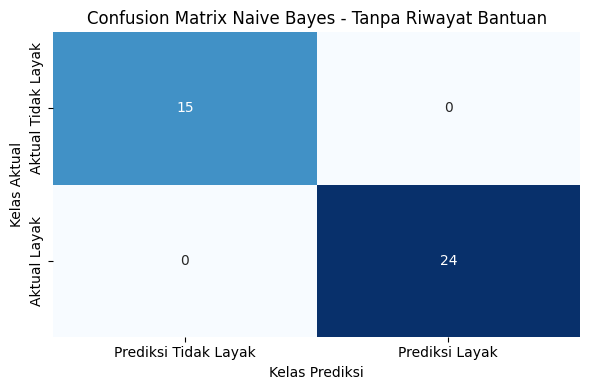


===== Naive Bayes - Tanpa Riwayat Bantuan =====

Confusion Matrix:
                    Prediksi Tidak Layak  Prediksi Layak
Aktual Tidak Layak                    15               0
Aktual Layak                           0              24

Classification Report:
              precision    recall  f1-score   support

 Tidak Layak     1.0000    1.0000    1.0000        15
       Layak     1.0000    1.0000    1.0000        24

    accuracy                         1.0000        39
   macro avg     1.0000    1.0000    1.0000        39
weighted avg     1.0000    1.0000    1.0000        39


5-FOLD CROSS-VALIDATION NAIVE BAYES - Dengan Riwayat Bantuan
Fold 1: Accuracy=1.0000 | Precision=1.0000 | Recall=1.0000 | F1-Score=1.0000
Fold 2: Accuracy=1.0000 | Precision=1.0000 | Recall=1.0000 | F1-Score=1.0000
Fold 3: Accuracy=1.0000 | Precision=1.0000 | Recall=1.0000 | F1-Score=1.0000
Fold 4: Accuracy=1.0000 | Precision=1.0000 | Recall=1.0000 | F1-Score=1.0000
Fold 5: Accuracy=1.0000 | Precision=1.00

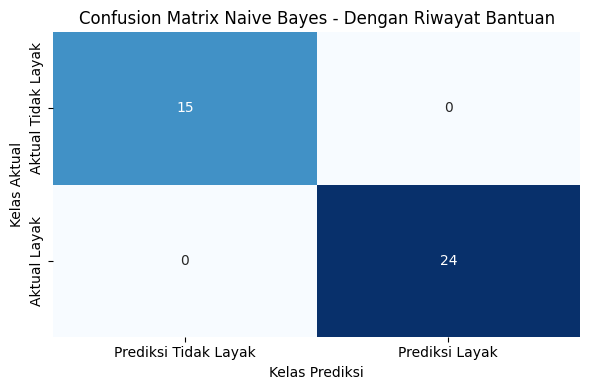


===== Naive Bayes - Dengan Riwayat Bantuan =====

Confusion Matrix:
                    Prediksi Tidak Layak  Prediksi Layak
Aktual Tidak Layak                    15               0
Aktual Layak                           0              24

Classification Report:
              precision    recall  f1-score   support

 Tidak Layak     1.0000    1.0000    1.0000        15
       Layak     1.0000    1.0000    1.0000        24

    accuracy                         1.0000        39
   macro avg     1.0000    1.0000    1.0000        39
weighted avg     1.0000    1.0000    1.0000        39



In [7]:

hasil_nb_tanpa, pred_nb_tanpa, model_nb_tanpa, encoder_nb_tanpa = (
    jalankan_naive_bayes(
        df,
        fitur_tanpa_riwayat,
        "Tanpa Riwayat Bantuan"
    )
)

# Naive Bayes dengan riwayat bantuan
hasil_nb_dengan, pred_nb_dengan, model_nb_dengan, encoder_nb_dengan = (
    jalankan_naive_bayes(
        df,
        fitur_dengan_riwayat,
        "Dengan Riwayat Bantuan"
    )
)

In [8]:
# ==========================================================
# 9. FUNGSI ENTROPY DAN C4.5 GAIN RATIO
# ==========================================================

def entropy(y):
    proporsi = y.value_counts(normalize=True)
    return -(proporsi * np.log2(proporsi)).sum()


class C45Classifier:
    """
    Implementasi C4.5 sederhana.
    Menggunakan Gain Ratio dan pre-pruning.
    Semua fitur harus berbentuk kategori.
    """

    def __init__(
        self,
        max_depth=5,
        min_samples_split=5,
        min_gain_ratio=0.01
     
    ):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_gain_ratio = min_gain_ratio

    def gain_ratio(self, data, feature):
        entropy_awal = entropy(data["_target"])
        total_data = len(data)

        entropy_setelah_split = 0
        split_info = 0

        for _, subset in data.groupby(feature, dropna=False):
            proporsi = len(subset) / total_data

            entropy_setelah_split += (
                proporsi * entropy(subset["_target"])
            )

            if proporsi > 0:
                split_info -= proporsi * np.log2(proporsi)

        information_gain = entropy_awal - entropy_setelah_split

        if split_info == 0:
            return 0

        return information_gain / split_info

    def build_tree(self, data, features, depth=0):
        target = data["_target"]
        kelas_default = target.mode().iloc[0]

        # Kondisi berhenti
        if target.nunique() == 1:
            return {
                "type": "leaf",
                "label": kelas_default
            }

        if len(features) == 0:
            return {
                "type": "leaf",
                "label": kelas_default
            }

        if depth >= self.max_depth:
            return {
                "type": "leaf",
                "label": kelas_default
            }

        if len(data) < self.min_samples_split:
            return {
                "type": "leaf",
                "label": kelas_default
            }

        # Menghitung Gain Ratio seluruh fitur
        gain_ratios = {
            feature: self.gain_ratio(data, feature)
            for feature in features
        }

        fitur_terbaik = max(gain_ratios, key=gain_ratios.get)
        nilai_gain_ratio = gain_ratios[fitur_terbaik]

        # Jika Gain Ratio terlalu kecil, jadikan leaf
        if nilai_gain_ratio < self.min_gain_ratio:
            return {
                "type": "leaf",
                "label": kelas_default
            }

        node = {
            "type": "node",
            "feature": fitur_terbaik,
            "default": kelas_default,
            "branches": {}
        }

        fitur_sisa = [
            feature
            for feature in features
            if feature != fitur_terbaik
        ]

        for nilai, subset in data.groupby(
            fitur_terbaik,
            dropna=False
        ):
            subset_baru = subset.drop(columns=[fitur_terbaik])

            node["branches"][nilai] = self.build_tree(
                subset_baru,
                fitur_sisa,
                depth + 1
            )

        return node

    def fit(self, X, y):
        data_train = X.copy().reset_index(drop=True)
        data_train["_target"] = pd.Series(y).reset_index(drop=True)

        self.tree_ = self.build_tree(
            data_train,
            list(X.columns)
        )

        return self

    def predict_one(self, row, node):
        if node["type"] == "leaf":
            return node["label"]

        feature = node["feature"]
        nilai = row[feature]

        if nilai not in node["branches"]:
            return node["default"]

        return self.predict_one(
            row,
            node["branches"][nilai]
        )

    def predict(self, X):
        return np.array([
            self.predict_one(row, self.tree_)
            for _, row in X.iterrows()
        ])

### Perbaikan confusion matrix C4.5

Urutan kelas ditetapkan secara eksplisit sebagai **TIDAK LAYAK → LAYAK**. Dengan demikian, posisi matriks adalah `[[TN, FP], [FN, TP]]` dan label heatmap tidak lagi tertukar.


In [9]:
# ==========================================================
# 10. MENJALANKAN C4.5
# ==========================================================

def jalankan_c45(df_model, fitur, nama_skenario):

    X = df_model[fitur].fillna("Tidak Diketahui").astype(str)
    y = df_model[TARGET].astype(str)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        stratify=y,
        random_state=RANDOM_STATE
    )

    model_c45 = C45Classifier(
        max_depth=5,
        min_samples_split=5,
        min_gain_ratio=0.01
    )

    model_c45.fit(X_train, y_train)

    y_pred = model_c45.predict(X_test)

    hasil = evaluasi_model(
        f"C4.5 - {nama_skenario}",
        y_test,
        y_pred
    )

    # PENTING: gunakan CLASS_ORDER secara eksplisit.
    # Tanpa labels=CLASS_ORDER, sklearn mengurutkan kelas secara alfabetis
    # menjadi [LAYAK, TIDAK LAYAK], sehingga tick heatmap sebelumnya tertukar.
    plot_confusion_matrix(
        y_test,
        y_pred,
        f"Confusion Matrix C4.5 - {nama_skenario}"
    )

    hasil_prediksi = X_test.copy()
    hasil_prediksi["AKTUAL"] = y_test.values
    hasil_prediksi["PREDIKSI"] = y_pred

    return hasil, hasil_prediksi, model_c45



===== C4.5 - Tanpa Riwayat Bantuan =====

Confusion Matrix:
                    Prediksi Tidak Layak  Prediksi Layak
Aktual Tidak Layak                    14               1
Aktual Layak                           0              24

Classification Report:
              precision    recall  f1-score   support

 Tidak Layak     1.0000    0.9333    0.9655        15
       Layak     0.9600    1.0000    0.9796        24

    accuracy                         0.9744        39
   macro avg     0.9800    0.9667    0.9726        39
weighted avg     0.9754    0.9744    0.9742        39



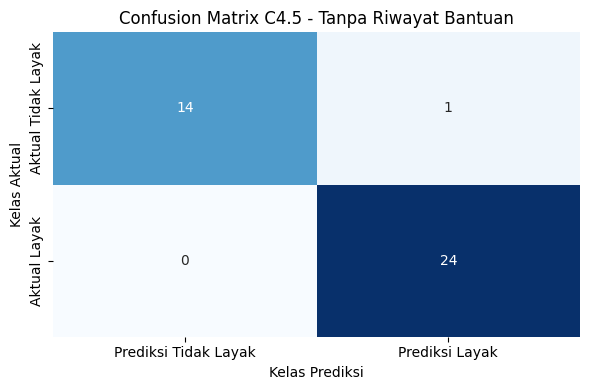


===== C4.5 - Dengan Riwayat Bantuan =====

Confusion Matrix:
                    Prediksi Tidak Layak  Prediksi Layak
Aktual Tidak Layak                    14               1
Aktual Layak                           0              24

Classification Report:
              precision    recall  f1-score   support

 Tidak Layak     1.0000    0.9333    0.9655        15
       Layak     0.9600    1.0000    0.9796        24

    accuracy                         0.9744        39
   macro avg     0.9800    0.9667    0.9726        39
weighted avg     0.9754    0.9744    0.9742        39



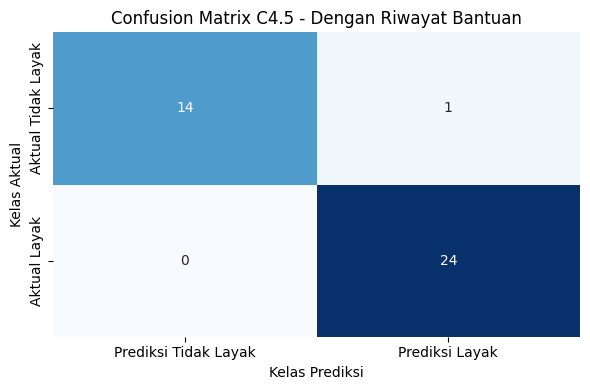

In [10]:
# C4.5 tanpa riwayat bantuan
hasil_c45_tanpa, pred_c45_tanpa, model_c45_tanpa = (
    jalankan_c45(
        df,
        fitur_tanpa_riwayat,
        "Tanpa Riwayat Bantuan"
    )
)

# C4.5 dengan riwayat bantuan
hasil_c45_dengan, pred_c45_dengan, model_c45_dengan = (
    jalankan_c45(
        df,
        fitur_dengan_riwayat,
        "Dengan Riwayat Bantuan"
    )
)

In [11]:
# ==========================================================
# 11. PERBANDINGAN HASIL MODEL
# ==========================================================

hasil_perbandingan = pd.DataFrame([
    hasil_nb_tanpa,
    hasil_nb_dengan,
    hasil_c45_tanpa,
    hasil_c45_dengan
])

hasil_perbandingan = hasil_perbandingan.sort_values(
    by=[
        "False_Positive",
        "Precision_LAYAK",
        "F1_LAYAK"
    ],
    ascending=[True, False, False]
)

print(hasil_perbandingan)

                                  Model  Accuracy  Precision_LAYAK  \
0   Naive Bayes - Tanpa Riwayat Bantuan    1.0000             1.00   
1  Naive Bayes - Dengan Riwayat Bantuan    1.0000             1.00   
2          C4.5 - Tanpa Riwayat Bantuan    0.9744             0.96   
3         C4.5 - Dengan Riwayat Bantuan    0.9744             0.96   

   Recall_LAYAK  F1_LAYAK  True_Negative  False_Positive  False_Negative  \
0           1.0    1.0000             15               0               0   
1           1.0    1.0000             15               0               0   
2           1.0    0.9796             14               1               0   
3           1.0    0.9796             14               1               0   

   True_Positive  
0             24  
1             24  
2             24  
3             24  


In [12]:
# ==========================================================
# 12. MENAMPILKAN ATURAN C4.5
# ==========================================================

def tampilkan_rules(node, indent=""):
    if node["type"] == "leaf":
        print(f"{indent}THEN {node['label']}")
        return

    for nilai, child in node["branches"].items():
        print(f"{indent}IF {node['feature']} = {nilai}")
        tampilkan_rules(child, indent + "   ")


print("ATURAN C4.5 DENGAN RIWAYAT BANTUAN")
tampilkan_rules(model_c45_dengan.tree_)

ATURAN C4.5 DENGAN RIWAYAT BANTUAN
IF KATEGORI_PENDAPATAN_PER_KAPITA = Rendah
   IF KATEGORI_TOTAL_PENDAPATAN = Rendah
      THEN LAYAK
   IF KATEGORI_TOTAL_PENDAPATAN = Sedang
      THEN TIDAK LAYAK
   IF KATEGORI_TOTAL_PENDAPATAN = Tinggi
      THEN TIDAK LAYAK
IF KATEGORI_PENDAPATAN_PER_KAPITA = Sangat Rendah
   IF JENIS USAHA/PEKERJAAN = Berdagang
      THEN LAYAK
   IF JENIS USAHA/PEKERJAAN = Transportasi
      THEN TIDAK LAYAK
   IF JENIS USAHA/PEKERJAAN = Wiraswasta
      THEN TIDAK LAYAK
IF KATEGORI_PENDAPATAN_PER_KAPITA = Sedang
   THEN TIDAK LAYAK
IF KATEGORI_PENDAPATAN_PER_KAPITA = Tinggi
   THEN TIDAK LAYAK


In [13]:
# ==========================================================
# 13. VALIDASI SILANG 5-FOLD
# ==========================================================

def cross_validation_model(df_model, fitur, n_splits=5):

    X = df_model[fitur].fillna("Tidak Diketahui").astype(str)
    y = df_model[TARGET].astype(str)

    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    hasil_cv = []

    for fold, (train_index, test_index) in enumerate(
        skf.split(X, y),
        start=1
    ):
        X_train = X.iloc[train_index]
        X_test = X.iloc[test_index]

        y_train = y.iloc[train_index]
        y_test = y.iloc[test_index]

        # ---------- Naive Bayes ----------
        encoder = OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1
        )

        X_train_nb = encoder.fit_transform(X_train).astype(int) + 1
        X_test_nb = encoder.transform(X_test).astype(int) + 1

        model_nb = CategoricalNB(alpha=1.0)
        model_nb.fit(X_train_nb, y_train)

        pred_nb = model_nb.predict(X_test_nb)

        cm_nb = confusion_matrix(
            y_test,
            pred_nb,
            labels=CLASS_ORDER
        )

        tn, fp, fn, tp = cm_nb.ravel()

        hasil_cv.append({
            "Fold": fold,
            "Model": "Naive Bayes",
            "Accuracy": accuracy_score(y_test, pred_nb),
            "Precision_LAYAK": precision_score(
                y_test,
                pred_nb,
                pos_label="LAYAK",
                zero_division=0
            ),
            "Recall_LAYAK": recall_score(
                y_test,
                pred_nb,
                pos_label="LAYAK",
                zero_division=0
            ),
            "F1_LAYAK": f1_score(
                y_test,
                pred_nb,
                pos_label="LAYAK",
                zero_division=0
            ),
            "False_Positive": fp
        })

        # ---------- C4.5 ----------
        model_c45 = C45Classifier(
            max_depth=5,
            min_samples_split=5,
            min_gain_ratio=0.01
        )

        model_c45.fit(X_train, y_train)

        pred_c45 = model_c45.predict(X_test)

        cm_c45 = confusion_matrix(
            y_test,
            pred_c45,
            labels=CLASS_ORDER
        )

        tn, fp, fn, tp = cm_c45.ravel()

        hasil_cv.append({
            "Fold": fold,
            "Model": "C4.5",
            "Accuracy": accuracy_score(y_test, pred_c45),
            "Precision_LAYAK": precision_score(
                y_test,
                pred_c45,
                pos_label="LAYAK",
                zero_division=0
            ),
            "Recall_LAYAK": recall_score(
                y_test,
                pred_c45,
                pos_label="LAYAK",
                zero_division=0
            ),
            "F1_LAYAK": f1_score(
                y_test,
                pred_c45,
                pos_label="LAYAK",
                zero_division=0
            ),
            "False_Positive": fp
        })

    hasil_detail = pd.DataFrame(hasil_cv)

    ringkasan = hasil_detail.groupby("Model").agg(
        Accuracy_Rata_Rata=("Accuracy", "mean"),
        Precision_LAYAK_Rata_Rata=("Precision_LAYAK", "mean"),
        Recall_LAYAK_Rata_Rata=("Recall_LAYAK", "mean"),
        F1_LAYAK_Rata_Rata=("F1_LAYAK", "mean"),
        False_Positive_Rata_Rata=("False_Positive", "mean")
    ).reset_index()

    return hasil_detail, ringkasan

In [14]:
detail_cv, ringkasan_cv = cross_validation_model(
    df,
    fitur_dengan_riwayat,
    n_splits=5
)

print("\nDETAIL HASIL CROSS VALIDATION:")
print(detail_cv)

print("\nRINGKASAN CROSS VALIDATION:")
print(ringkasan_cv)


DETAIL HASIL CROSS VALIDATION:
   Fold        Model  Accuracy  Precision_LAYAK  Recall_LAYAK  F1_LAYAK  \
0     1  Naive Bayes  1.000000             1.00           1.0  1.000000   
1     1         C4.5  1.000000             1.00           1.0  1.000000   
2     2  Naive Bayes  1.000000             1.00           1.0  1.000000   
3     2         C4.5  1.000000             1.00           1.0  1.000000   
4     3  Naive Bayes  1.000000             1.00           1.0  1.000000   
5     3         C4.5  1.000000             1.00           1.0  1.000000   
6     4  Naive Bayes  1.000000             1.00           1.0  1.000000   
7     4         C4.5  1.000000             1.00           1.0  1.000000   
8     5  Naive Bayes  1.000000             1.00           1.0  1.000000   
9     5         C4.5  0.947368             0.92           1.0  0.958333   

   False_Positive  
0               0  
1               0  
2               0  
3               0  
4               0  
5               0  
6 

In [15]:
# ==========================================================
# 14. MENYIMPAN HASIL PREDIKSI
# ==========================================================

pred_nb_dengan.to_csv(
    "artifacts/hasil_prediksi_naive_bayes.csv",
    index=False
)

pred_c45_dengan.to_csv(
    "artifacts/hasil_prediksi_c45.csv",
    index=False
)

hasil_perbandingan.to_csv(
    "artifacts/perbandingan_model.csv",
    index=False
)

ringkasan_cv.to_csv(
    "artifacts/cross_validation_model.csv",
    index=False
)

print("File hasil berhasil disimpan.")

File hasil berhasil disimpan.


In [16]:
import joblib
# Simpan seluruh komponen model
artifact_nb = {
    "model": model_nb_dengan,
    "encoder": encoder_nb_dengan,
    "fitur": fitur_dengan_riwayat,
    "target": TARGET,
    "threshold_layak": 0.75
}
joblib.dump(
    artifact_nb,
    "artifacts/model_naive_bayes_baznas.pkl"
)
print("Model Naive Bayes berhasil diexport.")

Model Naive Bayes berhasil diexport.
